In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

yield_curve = pd.read_csv(DATA_DIR / "yield_curve_history.csv")

yield_curve["CurveDate"] = pd.to_datetime(yield_curve["CurveDate"])

print("Shape:", yield_curve.shape)
display(yield_curve.head())
display(yield_curve.info())

Shape: (264, 8)


,CurveDate,Currency,Tenor_Years,TenorLabel,Yield,ZeroRate,ForwardRate,DiscountFactor
0,2022-12-30,INR,0.25,3M,0.062896,0.062438,0.067612,0.984866
1,2022-12-30,INR,0.50,6M,0.066424,0.066572,0.067280,0.968356
2,2022-12-30,INR,1.00,1Y,0.065468,0.066252,0.068171,0.938555
3,2022-12-30,INR,2.00,2Y,0.065904,0.064962,0.070420,0.880164
4,2022-12-30,INR,3.00,3Y,0.066903,0.066670,0.067334,0.823427


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CurveDate       264 non-null    datetime64[ns]
 1   Currency        264 non-null    object        
 2   Tenor_Years     264 non-null    float64       
 3   TenorLabel      264 non-null    object        
 4   Yield           264 non-null    float64       
 5   ZeroRate        264 non-null    float64       
 6   ForwardRate     264 non-null    float64       
 7   DiscountFactor  264 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(2)
memory usage: 16.6+ KB


None

In [4]:
print("Date Range:")
print(yield_curve["CurveDate"].min(), "to", yield_curve["CurveDate"].max())

print("\nCurrencies:")
print(yield_curve["Currency"].unique())

print("\nTenors:")
print(yield_curve[["Tenor_Years", "TenorLabel"]].drop_duplicates().sort_values("Tenor_Years"))

Date Range:
2022-12-30 00:00:00 to 2024-10-30 00:00:00

Currencies:
['INR']

Tenors:
    Tenor_Years TenorLabel
0          0.25         3M
1          0.50         6M
2          1.00         1Y
3          2.00         2Y
4          3.00         3Y
5          5.00         5Y
6          7.00         7Y
7         10.00        10Y
8         15.00        15Y
9         20.00        20Y
10        30.00        30Y


In [5]:
latest_date = yield_curve["CurveDate"].max()

latest_curve = (
    yield_curve[yield_curve["CurveDate"] == latest_date]
    .sort_values("Tenor_Years")
)

display(latest_curve)

,CurveDate,Currency,Tenor_Years,TenorLabel,Yield,ZeroRate,ForwardRate,DiscountFactor
253,2024-10-30,INR,0.25,3M,0.068725,0.069713,0.072059,0.983521
254,2024-10-30,INR,0.50,6M,0.070997,0.071454,0.075608,0.966286
255,2024-10-30,INR,1.00,1Y,0.070232,0.069457,0.072627,0.934377
256,2024-10-30,INR,2.00,2Y,0.070440,0.070796,0.071024,0.872721
257,2024-10-30,INR,3.00,3Y,0.071349,0.071584,0.072451,0.813218
258,2024-10-30,INR,5.00,5Y,0.074344,0.073997,0.077385,0.698688
259,2024-10-30,INR,7.00,7Y,0.074371,0.074424,0.078277,0.605229
260,2024-10-30,INR,10.00,10Y,0.077303,0.076694,0.077721,0.474921
261,2024-10-30,INR,15.00,15Y,0.078297,0.078651,0.083085,0.322793
262,2024-10-30,INR,20.00,20Y,0.079555,0.079344,0.082007,0.216324


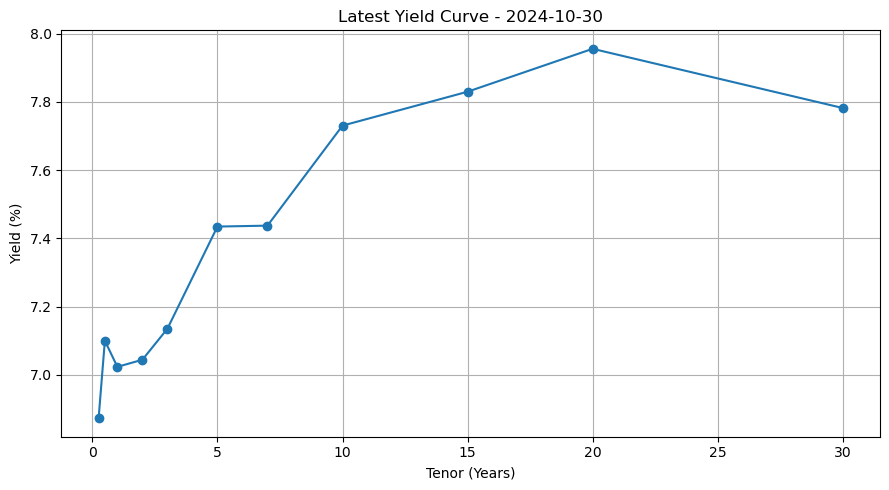

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["Yield"] * 100,
    marker="o"
)

plt.title(f"Latest Yield Curve - {latest_date.date()}")
plt.xlabel("Tenor (Years)")
plt.ylabel("Yield (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

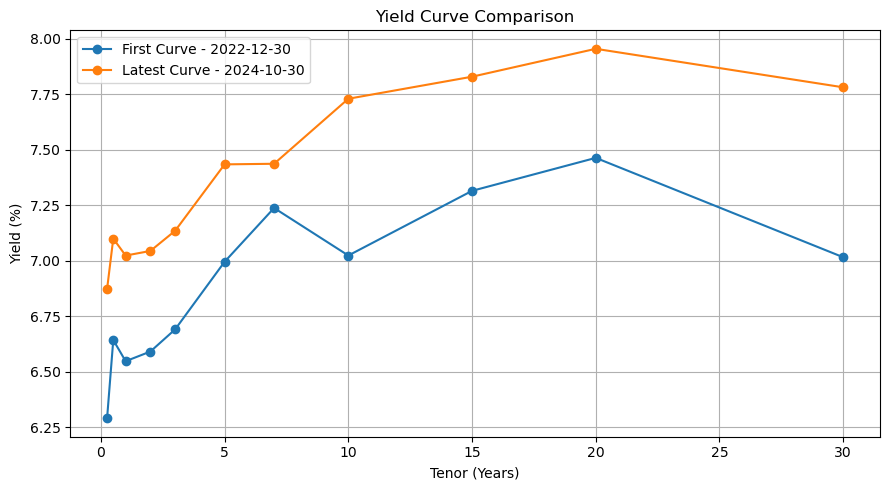

In [7]:
first_date = yield_curve["CurveDate"].min()

first_curve = (
    yield_curve[yield_curve["CurveDate"] == first_date]
    .sort_values("Tenor_Years")
)

plt.figure(figsize=(9, 5))

plt.plot(
    first_curve["Tenor_Years"],
    first_curve["Yield"] * 100,
    marker="o",
    label=f"First Curve - {first_date.date()}"
)

plt.plot(
    latest_curve["Tenor_Years"],
    latest_curve["Yield"] * 100,
    marker="o",
    label=f"Latest Curve - {latest_date.date()}"
)

plt.title("Yield Curve Comparison")
plt.xlabel("Tenor (Years)")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
curve_pivot = yield_curve.pivot_table(
    index="CurveDate",
    columns="TenorLabel",
    values="Yield"
)

display(curve_pivot.head())

TenorLabel,10Y,15Y,1Y,20Y,2Y,30Y,3M,3Y,5Y,6M,7Y
CurveDate,,,,,,,,,,,
2022-12-30,0.070234,0.073150,0.065468,0.074637,0.065904,0.070157,0.062896,0.066903,0.069952,0.066424,0.072377
2023-01-30,0.070392,0.071234,0.064662,0.072637,0.067981,0.072566,0.060384,0.068782,0.070725,0.066399,0.071672
2023-02-06,0.070348,0.073113,0.066587,0.071464,0.068053,0.071306,0.061462,0.071018,0.073020,0.062396,0.070952
2023-03-30,0.073786,0.074606,0.067893,0.073060,0.071465,0.071893,0.064730,0.071277,0.072507,0.066165,0.072696
2023-04-30,0.069715,0.074561,0.065440,0.075482,0.071460,0.072945,0.063941,0.069131,0.068470,0.064836,0.074709


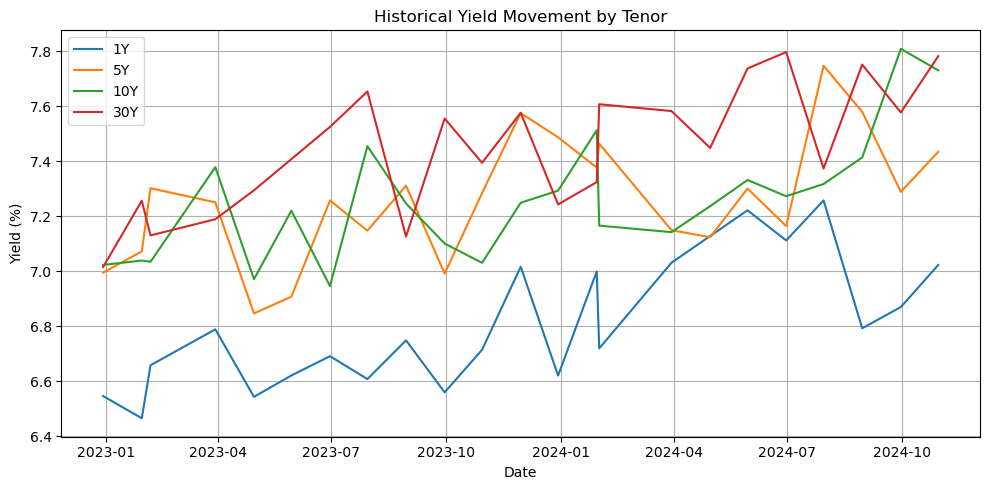

In [9]:
plt.figure(figsize=(10, 5))

for tenor in ["1Y", "5Y", "10Y", "30Y"]:
    if tenor in curve_pivot.columns:
        plt.plot(
            curve_pivot.index,
            curve_pivot[tenor] * 100,
            label=tenor
        )

plt.title("Historical Yield Movement by Tenor")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

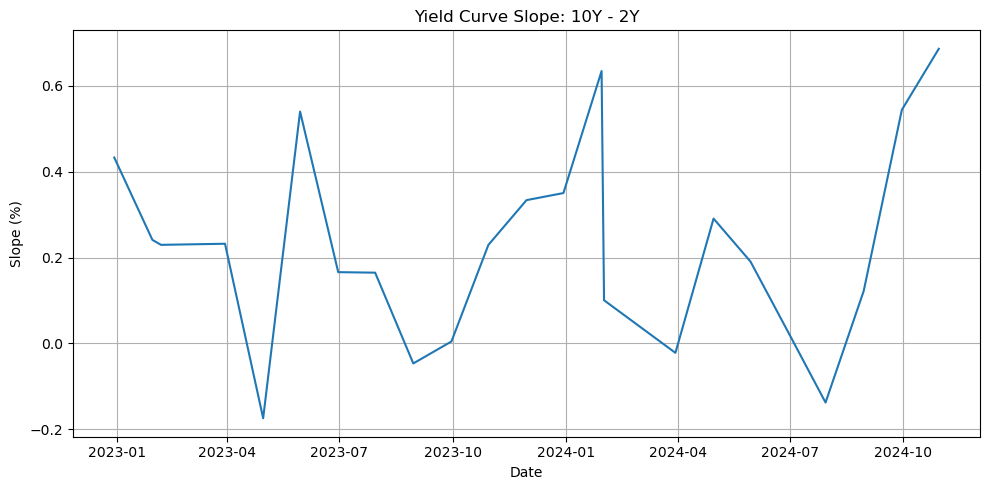

In [10]:
if "10Y" in curve_pivot.columns and "2Y" in curve_pivot.columns:
    curve_pivot["Slope_10Y_2Y"] = curve_pivot["10Y"] - curve_pivot["2Y"]

    plt.figure(figsize=(10, 5))
    plt.plot(curve_pivot.index, curve_pivot["Slope_10Y_2Y"] * 100)

    plt.title("Yield Curve Slope: 10Y - 2Y")
    plt.xlabel("Date")
    plt.ylabel("Slope (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

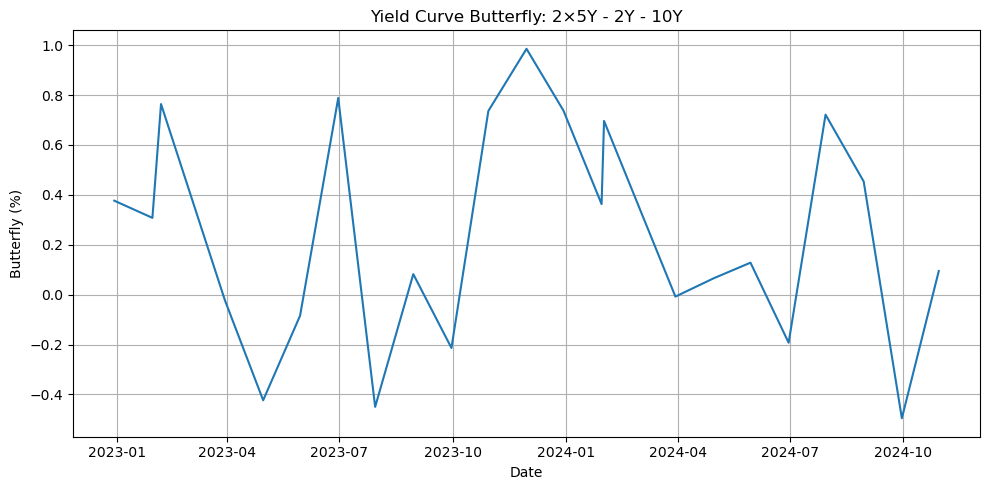

In [11]:
if all(col in curve_pivot.columns for col in ["2Y", "5Y", "10Y"]):
    curve_pivot["Butterfly_2Y_5Y_10Y"] = (
        2 * curve_pivot["5Y"] - curve_pivot["2Y"] - curve_pivot["10Y"]
    )

    plt.figure(figsize=(10, 5))
    plt.plot(curve_pivot.index, curve_pivot["Butterfly_2Y_5Y_10Y"] * 100)

    plt.title("Yield Curve Butterfly: 2×5Y - 2Y - 10Y")
    plt.xlabel("Date")
    plt.ylabel("Butterfly (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
latest_summary = pd.DataFrame({
    "Metric": [
        "Latest Curve Date",
        "Minimum Yield",
        "Maximum Yield",
        "Average Yield",
        "Shortest Tenor",
        "Longest Tenor"
    ],
    "Value": [
        latest_date.date(),
        f"{latest_curve['Yield'].min():.2%}",
        f"{latest_curve['Yield'].max():.2%}",
        f"{latest_curve['Yield'].mean():.2%}",
        latest_curve["Tenor_Years"].min(),
        latest_curve["Tenor_Years"].max()
    ]
})

display(latest_summary)

,Metric,Value
0,Latest Curve Date,2024-10-30
1,Minimum Yield,6.87%
2,Maximum Yield,7.96%
3,Average Yield,7.39%
4,Shortest Tenor,0.25
5,Longest Tenor,30.0


In [13]:
curve_pivot.to_csv(REPORTS_DIR / "yield_curve_pivot_day4.csv")
latest_curve.to_csv(REPORTS_DIR / "latest_yield_curve_day4.csv", index=False)
latest_summary.to_csv(REPORTS_DIR / "yield_curve_summary_day4.csv", index=False)

print("Day 4 yield curve analytics saved successfully.")

Day 4 yield curve analytics saved successfully.
